# Latent (phy-bottleneck) ablation — amplitude & bias

Merged study. Each **condition** applies an affine transform to the physiology
bottleneck `z_phy`:

$$z' = \text{amp} \cdot z + \text{bias}$$

* `amp = 1, bias = 0` → identity (unmodified baseline — does nothing).
* `amp` → multiplicative gain (0 = full ablation, >1 = amplified).
* `bias` → additive offset (− = under-eat, + = over-eat).

**Sections 1–3** compare the list of `(amp, bias)` `CONDITIONS`.
**Section 4** sweeps ONE axis (`SWEEP_AXIS`) with the other held at identity.


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from envs.env import FoodEnv
from agents.ppo import PPOAgent
from analysis.latent_analysis import capture_phy_bottleneck_shadow_data

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('Imports OK')


/Users/charithapalika/Desktop/Lab projects/Appetite modelling/FoodRL/FoodRL_cleaned_copies/utils/utils.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Imports OK


In [2]:
# ── Config ────────────────────────────────────────────────────────────────
SEED_TO_LOAD = 42
CKPT_NAME    = 'best'
CKPT_META    = f'results/training_checkpoints/checkpoints_{SEED_TO_LOAD}/ppo_agent_{CKPT_NAME}_meta.json'

BOTTLENECK_NAME = 'trunk_phy'   # which bottleneck to ablate (see list_bottlenecks())
DETERMINISTIC   = True          # argmax policy
EVAL_SEED       = 0             # env/policy re-seeded to this before EVERY condition,
                                # so all conditions see the same food menus

# ══════════════════════════════════════════════════════════════════════════
# SECTIONS 1-3 : the conditions to compare.
#   Each entry is (amp, bias). amp=1.0, bias=0.0 is the untouched baseline.
#   Label is auto-generated; override by adding a 3rd tuple element if wanted.
#   Examples:
#     (1.0,  0.0)   baseline (does nothing)
#     (0.1,  0.0)   shrink z_phy 10x         (amplitude ablation)
#     (100., 0.0)   blow z_phy up 100x
#     (1.0, -0.25)  subtract 0.25            (bias -> under-eat)
#     (1.0,  0.25)  add 0.25                 (bias -> over-eat)
#     (0.5,  0.25)  combine gain + offset
# ══════════════════════════════════════════════════════════════════════════
CONDITIONS = [
    (1.0, -1.05),
    (1.0, 0.0),
    (1.0, 1.75),
]
N_INFERENCE = 20               # inference episodes per condition

# ══════════════════════════════════════════════════════════════════════════
# SECTION 4 : the sweep. Vary ONE axis; the other is held at its identity value
#   (amplitude identity = 1.0, bias identity = 0.0).
# ══════════════════════════════════════════════════════════════════════════
SWEEP_AXIS   = 'bias'      # 'amplitude' or 'bias'
SWEEP_VALUES = np.linspace(-1.5,1.5,30) #np.array([-1.0, -0.25, -0.1, -0.05, 0.0,0.05, 0.1, 0.25, 1.0])#np.array([0.05, 0.1, 0.15, 1.0, 5.0, 250.0, 1000.0])
# for a bias sweep, e.g.: SWEEP_AXIS='bias'; SWEEP_VALUES=np.linspace(-0.4, 0.4, 41)
N_SWEEP      = 20              # inference episodes per sweep point

N_NEURONS_TO_PLOT = 3           # raw neurons to show in section 3
NEURONS_OVERRIDE  = [0, 1, 2]   # e.g. [13, 4, 0]; None -> highest variance at baseline

PLOT_DIR = 'results/plots_latent_ablation'
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Identity values + labels (derived) ─────────────────────────────────────
AMP_IDENTITY, BIAS_IDENTITY = 1.0, 0.0

def cond_label(amp, bias):
    """Compact human label for one (amp, bias) condition."""
    if amp == AMP_IDENTITY and bias == BIAS_IDENTITY:
        return 'baseline'
    parts = []
    if amp  != AMP_IDENTITY:  parts.append(f'amp={amp:g}')
    if bias != BIAS_IDENTITY: parts.append(f'bias={bias:+g}')
    return ', '.join(parts)

def norm_conditions(conds):
    """Accept (amp, bias) or (amp, bias, label); return list of dicts."""
    out = []
    for c in conds:
        if len(c) == 3:
            amp, bias, lab = c
        else:
            amp, bias = c; lab = cond_label(amp, bias)
        out.append({'amp': float(amp), 'bias': float(bias), 'label': lab})
    return out

COND = norm_conditions(CONDITIONS)
assert SWEEP_AXIS in ('amplitude', 'bias'), "SWEEP_AXIS must be 'amplitude' or 'bias'"

print(f'Checkpoint : {CKPT_META}')
print(f'Ablating   : {BOTTLENECK_NAME}')
print(f'Conditions : {[c["label"] for c in COND]}')
print(f'Sweep      : {SWEEP_AXIS} over {len(SWEEP_VALUES)} values x {N_SWEEP} episodes')


Checkpoint : results/training_checkpoints/checkpoints_42/ppo_agent_best_meta.json
Ablating   : trunk_phy
Conditions : ['bias=-1.05', 'baseline', 'bias=+1.75']
Sweep      : bias over 30 values x 20 episodes


In [3]:
# ── Load model ────────────────────────────────────────────────────────────
agent = PPOAgent.from_checkpoint(CKPT_META, device='cpu')
env   = agent.env

with open(CKPT_META) as f:
    ckpt_meta = json.load(f)

bl = agent.list_bottlenecks()
if BOTTLENECK_NAME not in bl:
    raise KeyError(f'{BOTTLENECK_NAME!r} not in this checkpoint. Available: {list(bl)}')

print(f"Seed {ckpt_meta['seed']} | best training return {ckpt_meta['best_return']:.2f}")
print(f'Ablating {BOTTLENECK_NAME}  (dim={bl[BOTTLENECK_NAME]["dim"]} neurons)')
print(f'Episode length: {env.max_steps} steps')

n_nut = env.num_nutrients
names = list(env.nutrient_names)
tgt, low, high = env._norm_targets, env._norm_target_low, env._norm_target_high


[FoodEnv] Loading  'glucose'  from  'food_dataset/serum_glucose.csv'
           min=70.0758  max=142.5123   foods=19   time_points=500
[FoodEnv] Loading  'peptides'  from  'food_dataset/small_peptides_absorbed.csv'
           min=0.0000  max=0.0018   foods=19   time_points=500
[FoodEnv] Loading  'fatty_acids'  from  'food_dataset/fatty_acids_absorbed.csv'
           min=0.0000  max=0.0007   foods=19   time_points=500
[FoodEnv] Ready — 19 foods | 3 time-series nutrients | 0 cumulative nutrients
[FoodEnv] Loading shadow nutrient 'fullness'  from  'food_dataset/fullness.csv'
[FoodEnv] Loading shadow nutrient 'hunger'  from  'food_dataset/hunger.csv'
[FoodEnv] Loading shadow nutrient 'cck'  from  'food_dataset/cck.csv'
[FoodEnv] Loading shadow nutrient 'ghrelin'  from  'food_dataset/ghrelin.csv'
[FoodEnv] Loading shadow nutrient 'glp_1'  from  'food_dataset/glp_1.csv'
[FoodEnv] Loading shadow nutrient 'pyy'  from  'food_dataset/pyy.csv'
[FoodEnv] Shadow nutrients ready — 6 signal(s): ['ful

In [4]:
# ── Core helper: run N inference episodes for one (amp, bias) condition ────
def run_condition(amp, bias, n_episodes, shadow=('hunger',)):
    """Apply z' = amp * z_phy + bias to BOTTLENECK_NAME, run n_episodes, and
    return per-step and per-episode arrays. The env + torch RNG are reset to
    EVAL_SEED first, so every condition sees the identical sequence of food
    menus. Amplitude is reset to 1.0 before each run so ONLY the requested
    (amp, bias) differs between conditions."""
    torch.manual_seed(EVAL_SEED)
    np.random.seed(EVAL_SEED)
    env.reset(seed=EVAL_SEED)

    agent.reset_amplitudes()                       # neutral multiplicative gain
    agent.set_amplitude(BOTTLENECK_NAME, float(amp))
    agent.set_bias(BOTTLENECK_NAME, float(bias))

    z, targets, ei, meta = capture_phy_bottleneck_shadow_data(
        agent, env, n_episodes=n_episodes, deterministic=DETERMINISTIC,
        network='actor', shadow_names=list(shadow),
    )

    phy   = meta['phy_state'][:, :n_nut]
    rew   = meta['reward']
    awake = meta['is_awake']
    ate   = (meta['action_sum'] > 0) & awake       # real consumption (env ignores sleep)

    below  = np.minimum(0.0, phy - low[None, :])
    above  = np.maximum(0.0, phy - high[None, :])
    signed = (below + above).mean(axis=1)
    dist   = np.linalg.norm(phy - tgt[None, :], axis=1)

    cal_cum = meta.get('calories_cumulative', np.zeros_like(rew))

    per_ep = pd.DataFrame([{
        'episode':           e,
        'total_reward':      float(rew[ei == e].sum()),
        'avg_reward':        float(rew[ei == e].mean()),
        'total_distance':    float(dist[ei == e].sum()),
        'avg_distance':      float(dist[ei == e].mean()),
        'total_consumption': int(ate[ei == e].sum()),
        'total_calories':    float(cal_cum[ei == e].max()) if (ei == e).any() else 0.0,
        'avg_signed_err':    float(signed[ei == e].mean()),
    } for e in range(n_episodes)])

    return {'amp': amp, 'bias': bias, 'z': z, 'episode_idx': ei, 'meta': meta,
            'phy': phy, 'rew': rew, 'dist': dist, 'signed': signed, 'ate': ate,
            'awake': awake, 'cal_cum': cal_cum, 'per_ep': per_ep}


def stack_per_step(vec, ei, n_ep):
    """(n_ep, T_min) matrix of a per-step quantity."""
    lens = [int((ei == e).sum()) for e in range(n_ep)]
    T = min(lens)
    return np.stack([vec[ei == e][:T] for e in range(n_ep)])


def mean_sem(M):
    mu = M.mean(axis=0)
    sd = M.std(axis=0, ddof=1) if M.shape[0] > 1 else np.zeros(M.shape[1])
    return mu, sd, sd / np.sqrt(M.shape[0])


def sleep_windows_from_awake(a):
    wins, in_s, st = [], False, 0
    for t, v in enumerate(a):
        if not v and not in_s:
            in_s, st = True, t
        elif v and in_s:
            in_s = False; wins.append((st, t))
    if in_s:
        wins.append((st, len(a)))
    return wins


def shade_sleep(ax, wins, t_max):
    for k, (ws, we) in enumerate(wins):
        ax.axvspan(ws, min(we, t_max), alpha=0.10, color='navy',
                   label='Sleep' if k == 0 else '')

print('Helpers defined.')


Helpers defined.


## 1. Per-step reward / distance / signed error for each condition


In [5]:
# ── Run every condition ───────────────────────────────────────────────────
runs = {}
for c in COND:
    r = run_condition(c['amp'], c['bias'], N_INFERENCE)
    runs[c['label']] = r
    pe = r['per_ep']
    print(f"{c['label']:>22}  return={pe.total_reward.mean():8.2f}  "
          f"food_items={pe.total_consumption.mean():6.2f}  "
          f"kcal={pe.total_calories.mean():8.1f}  "
          f"avg_dist={pe.avg_distance.mean():.4f}  "
          f"signed_err={pe.avg_signed_err.mean():+.4f}")
agent.reset_amplitudes()
agent.set_bias(BOTTLENECK_NAME, 0.0)

# Flag conditions that produced identical behaviour (a degenerate policy — e.g.
# the agent never eats — makes two conditions indistinguishable).
sig = {c['label']: (round(runs[c['label']]['per_ep'].total_reward.mean(), 6),
                    round(runs[c['label']]['per_ep'].total_consumption.mean(), 6))
       for c in COND}
seen = {}
for lab, s in sig.items():
    seen.setdefault(s, []).append(lab)
for s, labs in seen.items():
    if len(labs) > 1:
        warnings.warn(
            f'Conditions {labs} produced IDENTICAL behaviour '
            f'(return={s[0]}, food items={s[1]}). Their curves will overlap exactly.',
            RuntimeWarning)


Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
            bias=-1.05  return=  109.09  food_items=  4.85  kcal=  1822.8  avg_dist=0.3465  signed_err=-0.0560
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
              baseline  return=  174.72  food_items= 10.65  kcal=  4310.5  avg_dist=0.1882  signed_err=-0.0085
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
            bias=+1.75  return=   46.72  food_items= 27.75  kcal= 11042.9  avg_dist=0.6017  signed_err=+0.1699


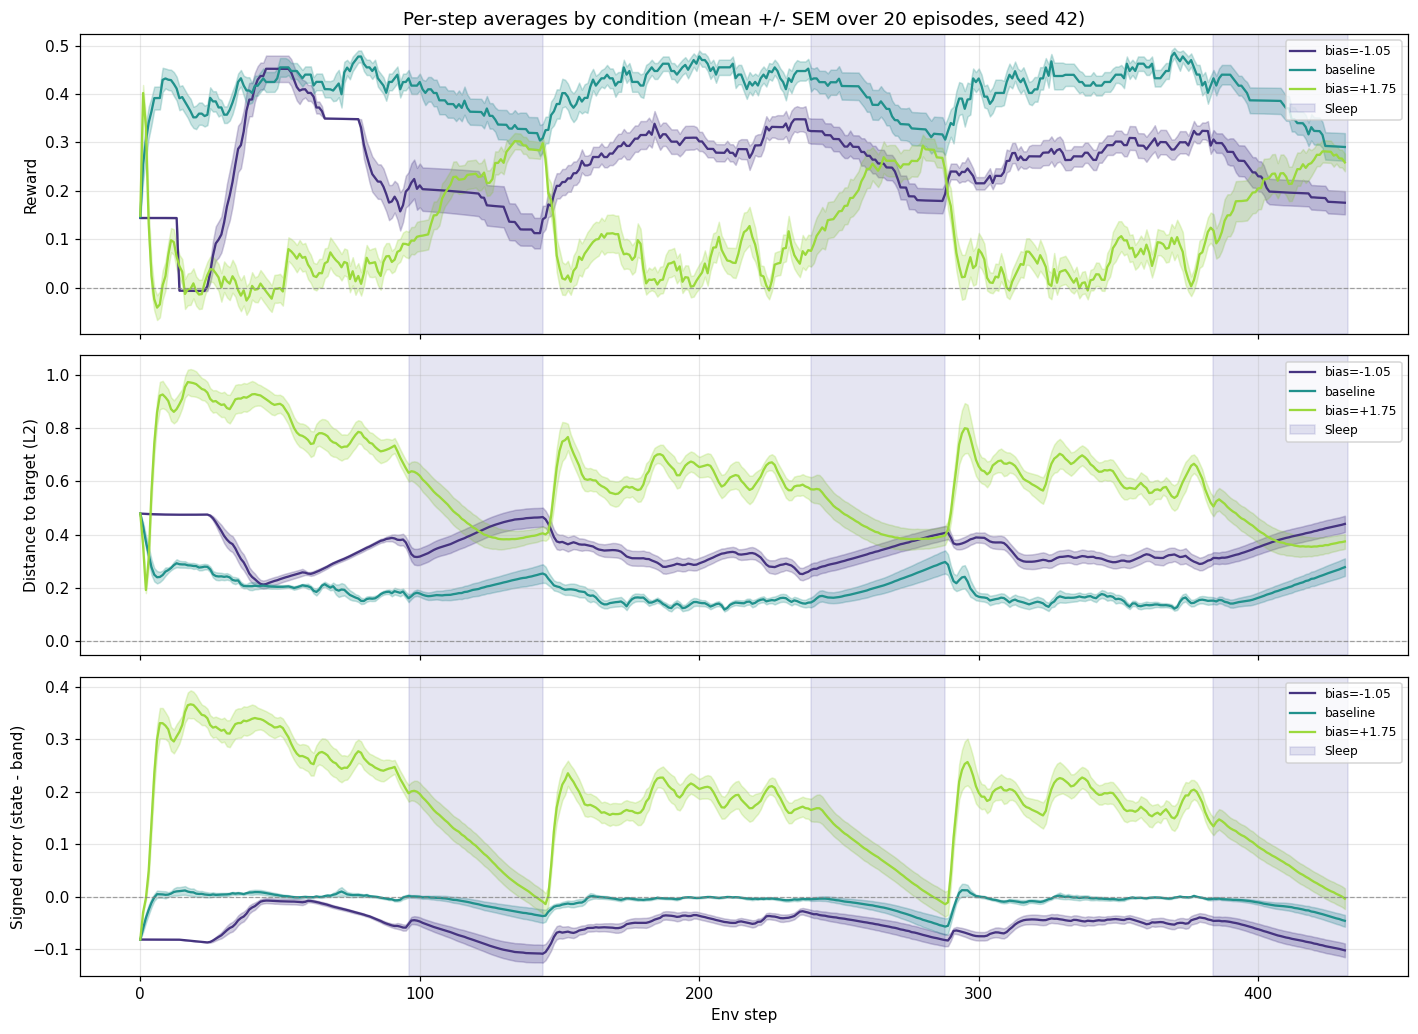

Saved results/plots_latent_ablation/perstep_by_condition.png (+ .pkl, + per_episode_by_condition.pkl)


In [6]:
# ── Plot: per-step curves, one line+band per condition ────────────────────
COLORS = plt.cm.viridis(np.linspace(0.15, 0.85, len(COND)))
first = COND[0]['label']
sleep_wins = sleep_windows_from_awake(
    runs[first]['awake'][runs[first]['episode_idx'] == 0])

panels = [('rew',    'Reward'),
          ('dist',   'Distance to target (L2)'),
          ('signed', 'Signed error (state - band)')]

fig, axes = plt.subplots(3, 1, figsize=(13, 9.5), sharex=True)
rows_csv = []

for ax, (key, label) in zip(axes, panels):
    for c, col in zip(COND, COLORS):
        r = runs[c['label']]
        M = stack_per_step(r[key], r['episode_idx'], N_INFERENCE)
        mu, sd, sem = mean_sem(M)
        ts = np.arange(len(mu))
        ax.plot(ts, mu, lw=1.5, color=col, label=c['label'])
        ax.fill_between(ts, mu - sem, mu + sem, color=col, alpha=0.25)
        for t_i in range(len(mu)):
            rows_csv.append({'condition': c['label'], 'amp': c['amp'], 'bias': c['bias'],
                             'metric': key, 'step': t_i,
                             'mean': mu[t_i], 'std': sd[t_i], 'sem': sem[t_i]})
    ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.7)
    shade_sleep(ax, sleep_wins, len(mu))
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_title(f'Per-step averages by condition '
                  f'(mean +/- SEM over {N_INFERENCE} episodes, seed {SEED_TO_LOAD})',
                  fontsize=12)
axes[-1].set_xlabel('Env step')
fig.tight_layout()

fig.savefig(os.path.join(PLOT_DIR, 'perstep_by_condition.png'), bbox_inches='tight')
plt.show()

pd.DataFrame(rows_csv).to_pickle(
    os.path.join(PLOT_DIR, 'perstep_by_condition.pkl'))
pd.concat([r['per_ep'].assign(condition=lab) for lab, r in runs.items()]).to_pickle(
    os.path.join(PLOT_DIR, 'per_episode_by_condition.pkl'))
print(f'Saved {PLOT_DIR}/perstep_by_condition.png (+ .pkl, + per_episode_by_condition.pkl)')


## 2. Nutrient trajectories per condition (one instance)


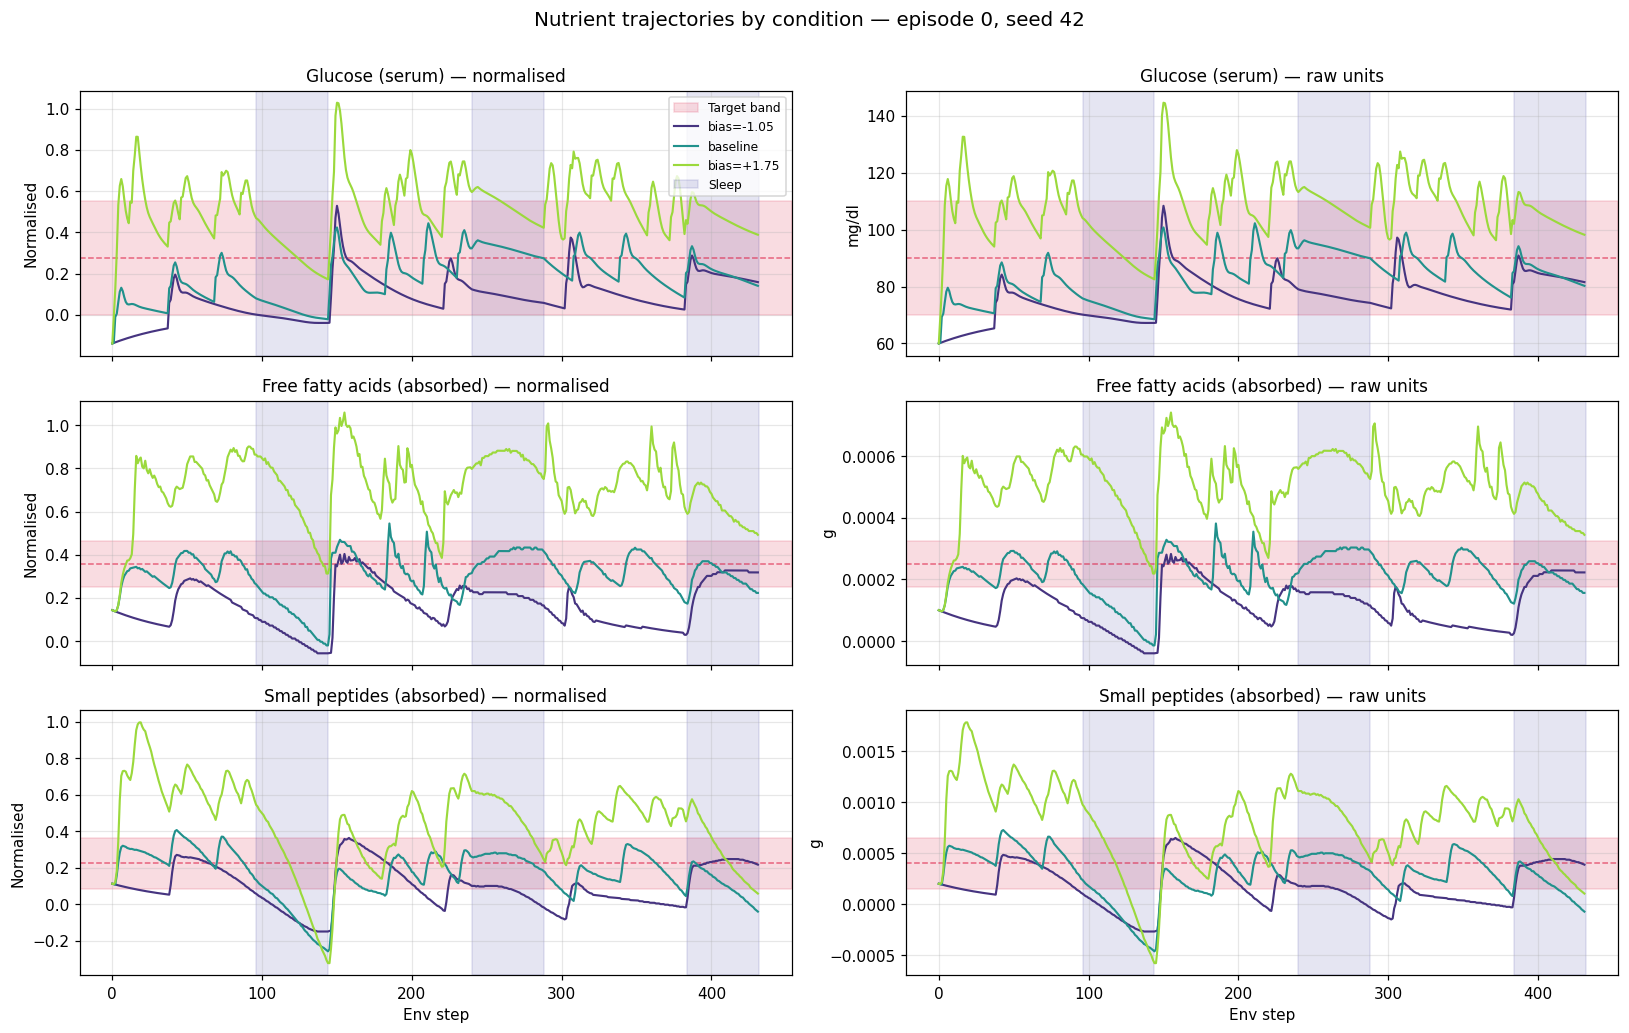

Saved results/plots_latent_ablation/nutrients_by_condition_ep0.png


In [7]:
# ── Nutrient trajectories, one episode per condition ──────────────────────
INSTANCE_EP = 0

DISPLAY = {
    'glucose':     ('Glucose (serum)',             'mg/dl'),
    'fatty_acids': ('Free fatty acids (absorbed)', 'g'),
    'peptides':    ('Small peptides (absorbed)',   'g'),
}
PLOT_ORDER = [n for n in ['glucose', 'fatty_acids', 'peptides'] if n in names]

fig, axes = plt.subplots(len(PLOT_ORDER), 2, figsize=(15, 3.1 * len(PLOT_ORDER)),
                         sharex=True)
if len(PLOT_ORDER) == 1:
    axes = axes[None, :]

for r_i, nm in enumerate(PLOT_ORDER):
    i = names.index(nm)
    label, unit = DISPLAY[nm]
    v_min, v_max = env._nutrient_mins[nm], env._nutrient_maxs[nm]
    rng = v_max - v_min

    axL, axR = axes[r_i, 0], axes[r_i, 1]
    axL.axhspan(low[i], high[i], alpha=0.15, color='crimson', label='Target band')
    axL.axhline(tgt[i], ls='--', color='crimson', lw=1.0, alpha=0.6)
    axR.axhspan(low[i]*rng + v_min, high[i]*rng + v_min, alpha=0.15, color='crimson')
    axR.axhline(tgt[i]*rng + v_min, ls='--', color='crimson', lw=1.0, alpha=0.6)

    for c, col in zip(COND, COLORS):
        r = runs[c['label']]
        m = r['episode_idx'] == INSTANCE_EP
        y = r['phy'][m][:, i]
        ts = np.arange(len(y))
        axL.plot(ts, y, lw=1.4, color=col, label=c['label'])
        axR.plot(ts, y*rng + v_min, lw=1.4, color=col)

    shade_sleep(axL, sleep_wins, len(ts))
    shade_sleep(axR, sleep_wins, len(ts))
    axL.set_ylabel('Normalised'); axL.set_title(f'{label} — normalised', fontsize=11)
    axR.set_ylabel(unit);         axR.set_title(f'{label} — raw units', fontsize=11)
    axL.grid(alpha=0.3); axR.grid(alpha=0.3)
    if r_i == 0:
        axL.legend(fontsize=8, loc='upper right')

axes[-1, 0].set_xlabel('Env step'); axes[-1, 1].set_xlabel('Env step')
fig.suptitle(f'Nutrient trajectories by condition — episode {INSTANCE_EP}, '
             f'seed {SEED_TO_LOAD}', fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'nutrients_by_condition_ep{INSTANCE_EP}.png'),
            bbox_inches='tight')
plt.show()
print(f'Saved {PLOT_DIR}/nutrients_by_condition_ep{INSTANCE_EP}.png')


## 3. Raw bottleneck visualisation per condition


z_phy dim=16; showing neurons [0, 1, 2] (manual)


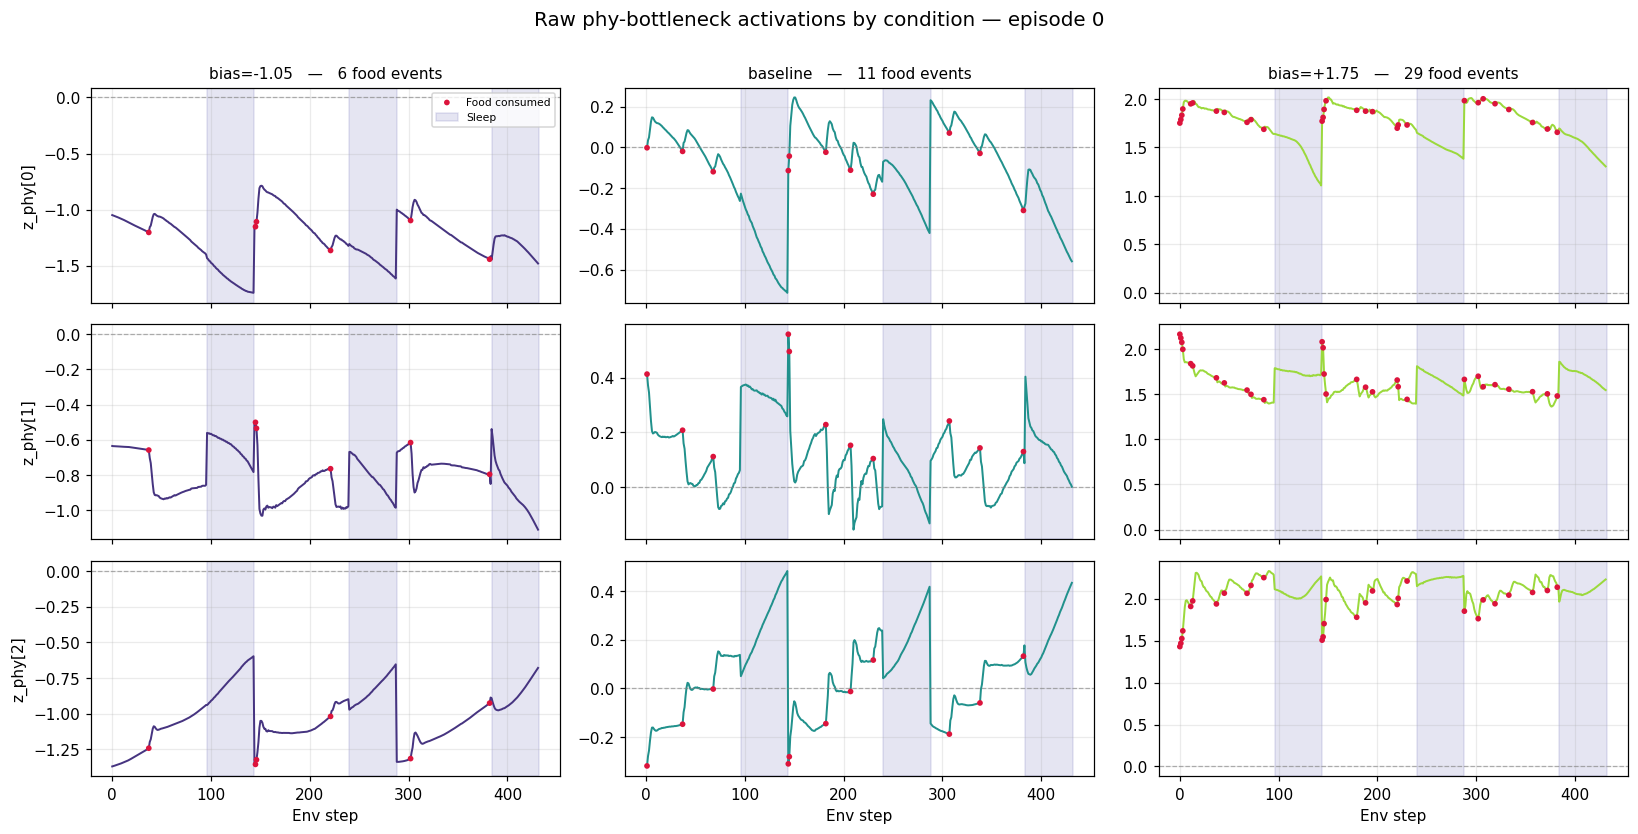

Saved results/plots_latent_ablation/z_phy_by_condition_ep0.png


In [8]:
# ── Raw z_phy grid: neurons x conditions ──────────────────────────────────
z_dim = runs[COND[0]['label']]['z'].shape[1]
ref   = runs.get('baseline', runs[COND[0]['label']])   # select neurons at baseline
if NEURONS_OVERRIDE is not None:
    sel = [int(j) for j in NEURONS_OVERRIDE]
else:
    sel = [int(j) for j in np.argsort(ref['z'].std(axis=0))[::-1][:N_NEURONS_TO_PLOT]]
print(f'z_phy dim={z_dim}; showing neurons {sel} '
      f'({"manual" if NEURONS_OVERRIDE is not None else "highest variance at baseline"})')

fig, axes = plt.subplots(len(sel), len(COND),
                         figsize=(5.0 * len(COND), 2.5 * len(sel)),
                         sharex=True, squeeze=False)

for c_i, (c, col) in enumerate(zip(COND, COLORS)):
    r  = runs[c['label']]
    m  = r['episode_idx'] == INSTANCE_EP
    zb = r['z'][m]
    ate_b = r['ate'][m]
    eat_steps = np.where(ate_b)[0]
    ts = np.arange(zb.shape[0])
    for r_i, j in enumerate(sel):
        ax = axes[r_i][c_i]
        ax.plot(ts, zb[:, j], lw=1.3, color=col)
        ax.scatter(eat_steps, zb[eat_steps, j], s=14, color='crimson', zorder=5,
                   edgecolors='none', label='Food consumed' if r_i == 0 else None)
        ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.6)
        shade_sleep(ax, sleep_wins, len(ts))
        ax.grid(alpha=0.25)
        if c_i == 0:
            ax.set_ylabel(f'z_phy[{j}]')
        if r_i == 0:
            ax.set_title(f"{c['label']}   —   {len(eat_steps)} food events", fontsize=10)
            if c_i == 0:
                ax.legend(fontsize=7, loc='upper right')

for ax in axes[-1]:
    ax.set_xlabel('Env step')
fig.suptitle(f'Raw phy-bottleneck activations by condition — episode {INSTANCE_EP}',
             fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'z_phy_by_condition_ep{INSTANCE_EP}.png'),
            bbox_inches='tight')
plt.show()
print(f'Saved {PLOT_DIR}/z_phy_by_condition_ep{INSTANCE_EP}.png')


## 4. Sweep along one axis

Varies `SWEEP_AXIS` (`amplitude` or `bias`) over `SWEEP_VALUES`, holding the
other axis at its identity value (amp=1 / bias=0). Reference lines mark the
baseline; for an amplitude sweep, amp=0 is the full-ablation reference.


In [ ]:
# ── Run the sweep ─────────────────────────────────────────────────────────
def run_sweep_point(value):
    """Run one sweep value on the chosen axis, other axis at identity."""
    if SWEEP_AXIS == 'amplitude':
        return run_condition(float(value), BIAS_IDENTITY, N_SWEEP)
    return run_condition(AMP_IDENTITY, float(value), N_SWEEP)

sweep_rows = []
for k, val in enumerate(SWEEP_VALUES):
    r  = run_sweep_point(val)
    pe = r['per_ep']
    sweep_rows.append({
        'value': float(val),
        'reward_mean': pe.total_reward.mean(),
        'reward_sem':  pe.total_reward.std(ddof=1) / np.sqrt(N_SWEEP),
        'consumption_mean': pe.total_consumption.mean(),
        'consumption_sem':  pe.total_consumption.std(ddof=1) / np.sqrt(N_SWEEP),
        'calories_mean': pe.total_calories.mean(),
        'calories_sem':  pe.total_calories.std(ddof=1) / np.sqrt(N_SWEEP),
        'distance_mean': pe.total_distance.mean(),
        'distance_sem':  pe.total_distance.std(ddof=1) / np.sqrt(N_SWEEP),
        'signed_err_mean': pe.avg_signed_err.mean(),
    })
    if (k + 1) % 5 == 0 or k == len(SWEEP_VALUES) - 1:
        print(f'  [{k+1:2d}/{len(SWEEP_VALUES)}] {SWEEP_AXIS}={val:+.3f}  '
              f'reward={pe.total_reward.mean():8.2f}  '
              f'items={pe.total_consumption.mean():6.2f}  '
              f'kcal={pe.total_calories.mean():8.1f}')
agent.reset_amplitudes()
agent.set_bias(BOTTLENECK_NAME, 0.0)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_pickle(os.path.join(PLOT_DIR, f'{SWEEP_AXIS}_sweep.pkl'))
print(f'\nSaved {PLOT_DIR}/{SWEEP_AXIS}_sweep.pkl')
display(sweep_df.round(4).head(12))


Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
  [ 5/30] bias=-1.086  reward=  102.66  items=  4.25  kcal=  1669.7
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
Pooled 20 episodes -> 8640 total steps, dim 16 (network='actor', signature='phy')
  [10/30] bias=-0.569  reward=  149.04  items=  7.20  kcal=  2975.7
Pooled 20 episodes -> 8640 total steps, dim 

,value,reward_mean,reward_sem,consumption_mean,consumption_sem,calories_mean,calories_sem,distance_mean,distance_sem,signed_err_mean
0,-1.5000,15.3224,0.0000,0.00,0.0000,0.0000,0.0000,214.3102,0.0000,-0.1059
1,-1.3966,60.8097,4.6847,2.00,0.1257,664.6060,45.4251,180.2911,2.2546,-0.0798
2,-1.2931,94.3864,2.0046,3.35,0.1666,1288.2992,56.7829,164.3549,1.9338,-0.0675
3,-1.1897,98.8645,2.2576,3.65,0.1313,1434.1355,48.0266,160.9818,2.3619,-0.0644
4,-1.0862,102.6627,1.8356,4.25,0.1758,1669.7253,57.3203,157.2656,2.0586,-0.0623
5,-0.9828,116.2219,1.9439,5.25,0.2280,2002.3153,72.5489,145.4071,1.9828,-0.0534
6,-0.8793,131.9724,1.9721,6.10,0.1762,2372.2659,65.4974,129.0024,1.8945,-0.0400
7,-0.7759,137.8585,2.3058,6.50,0.2115,2615.2816,62.2164,123.6685,2.5000,-0.0362
8,-0.6724,144.1880,2.0701,6.70,0.2065,2785.8417,62.4070,115.4607,2.4078,-0.0314
9,-0.5690,149.0374,2.2270,7.20,0.1864,2975.7118,65.3570,111.0790,2.4515,-0.0277


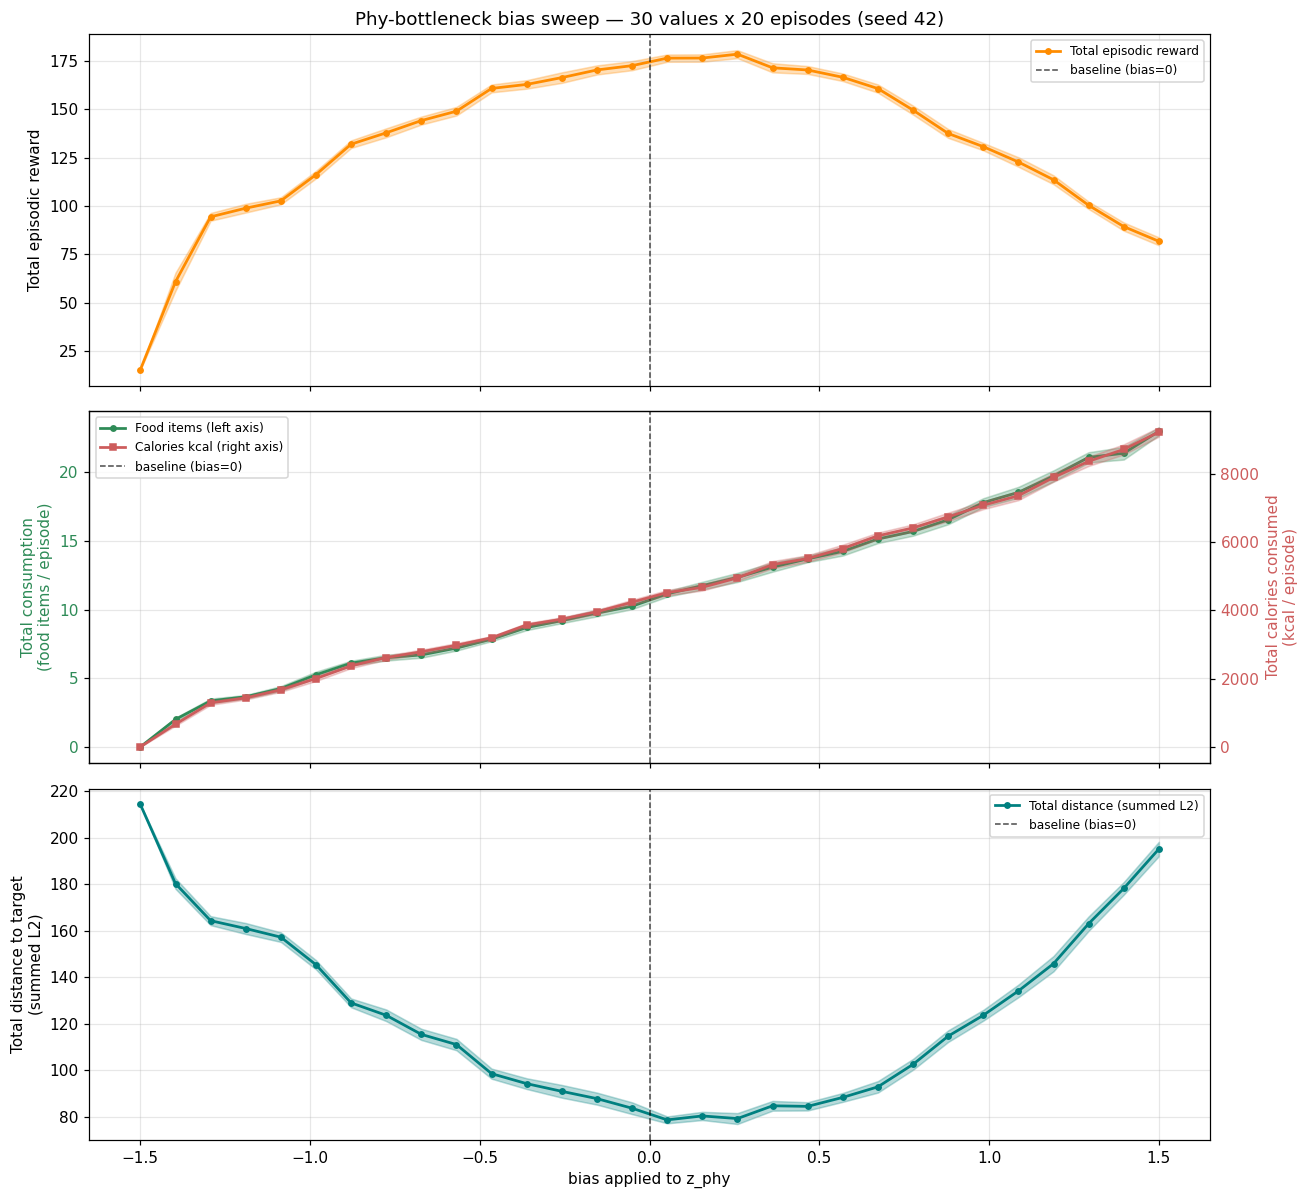

Under-eating (signed error < 0): bias range [-1.500, +0.259]
Over-eating  (signed error > 0): bias range [+0.362, +1.500]
Peak reward at bias +0.259 (reward=178.55, items=12.3, kcal=4952)
Saved results/plots_latent_ablation/bias_sweep_line.png


In [ ]:
# ── Plot the sweep (line + SEM band) ──────────────────────────────────────
a = sweep_df['value'].values
BASELINE_VAL = AMP_IDENTITY if SWEEP_AXIS == 'amplitude' else BIAS_IDENTITY


def _band(ax, key, col, label, marker='o'):
    mu, sem = sweep_df[f'{key}_mean'].values, sweep_df[f'{key}_sem'].values
    ln, = ax.plot(a, mu, color=col, lw=1.8, marker=marker, ms=3.5, label=label)
    ax.fill_between(a, mu - sem, mu + sem, color=col, alpha=0.28)
    return ln


def _refs(ax):
    refs = [ax.axvline(BASELINE_VAL, color='black', ls='--', lw=1.0, alpha=0.7,
                       label=f'baseline ({SWEEP_AXIS}={BASELINE_VAL:g})')]
    if SWEEP_AXIS == 'amplitude':
        refs.append(ax.axvline(0.0, color='grey', ls=':', lw=1.0, alpha=0.7,
                               label='full ablation (amp=0)'))
    return refs


fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

ax = axes[0]
l = _band(ax, 'reward', 'darkorange', 'Total episodic reward')
ax.set_ylabel('Total episodic reward'); ax.grid(alpha=0.3)
ax.legend(handles=[l, *_refs(ax)], fontsize=8, loc='best')

ax   = axes[1]
ax_c = ax.twinx()
l_items = _band(ax,   'consumption', 'seagreen',  'Food items (left axis)')
l_kcal  = _band(ax_c, 'calories',    'indianred', 'Calories kcal (right axis)', marker='s')
ax.set_ylabel('Total consumption\n(food items / episode)', color='seagreen')
ax_c.set_ylabel('Total calories consumed\n(kcal / episode)', color='indianred')
ax.tick_params(axis='y', labelcolor='seagreen')
ax_c.tick_params(axis='y', labelcolor='indianred')
ax.grid(alpha=0.3); ax_c.grid(False)
ax.legend(handles=[l_items, l_kcal, *_refs(ax)], fontsize=8, loc='upper left')

ax = axes[2]
l = _band(ax, 'distance', 'teal', 'Total distance (summed L2)')
ax.set_ylabel('Total distance to target\n(summed L2)'); ax.grid(alpha=0.3)
ax.legend(handles=[l, *_refs(ax)], fontsize=8, loc='best')

axes[0].set_title(f'Phy-bottleneck {SWEEP_AXIS} sweep — {len(SWEEP_VALUES)} values '
                  f'x {N_SWEEP} episodes (seed {SEED_TO_LOAD})', fontsize=12)
axes[-1].set_xlabel(f'{SWEEP_AXIS} applied to z_phy')
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'{SWEEP_AXIS}_sweep_line.png'), bbox_inches='tight')
plt.show()

under = sweep_df[sweep_df.signed_err_mean < 0]
over  = sweep_df[sweep_df.signed_err_mean > 0]
if len(under):
    print(f'Under-eating (signed error < 0): {SWEEP_AXIS} range '
          f'[{under.value.min():+.3f}, {under.value.max():+.3f}]')
if len(over):
    print(f'Over-eating  (signed error > 0): {SWEEP_AXIS} range '
          f'[{over.value.min():+.3f}, {over.value.max():+.3f}]')
best = sweep_df.loc[sweep_df['reward_mean'].idxmax()]
print(f'Peak reward at {SWEEP_AXIS} {best["value"]:+.3f} '
      f'(reward={best["reward_mean"]:.2f}, items={best["consumption_mean"]:.1f}, '
      f'kcal={best["calories_mean"]:.0f})')
print(f'Saved {PLOT_DIR}/{SWEEP_AXIS}_sweep_line.png')


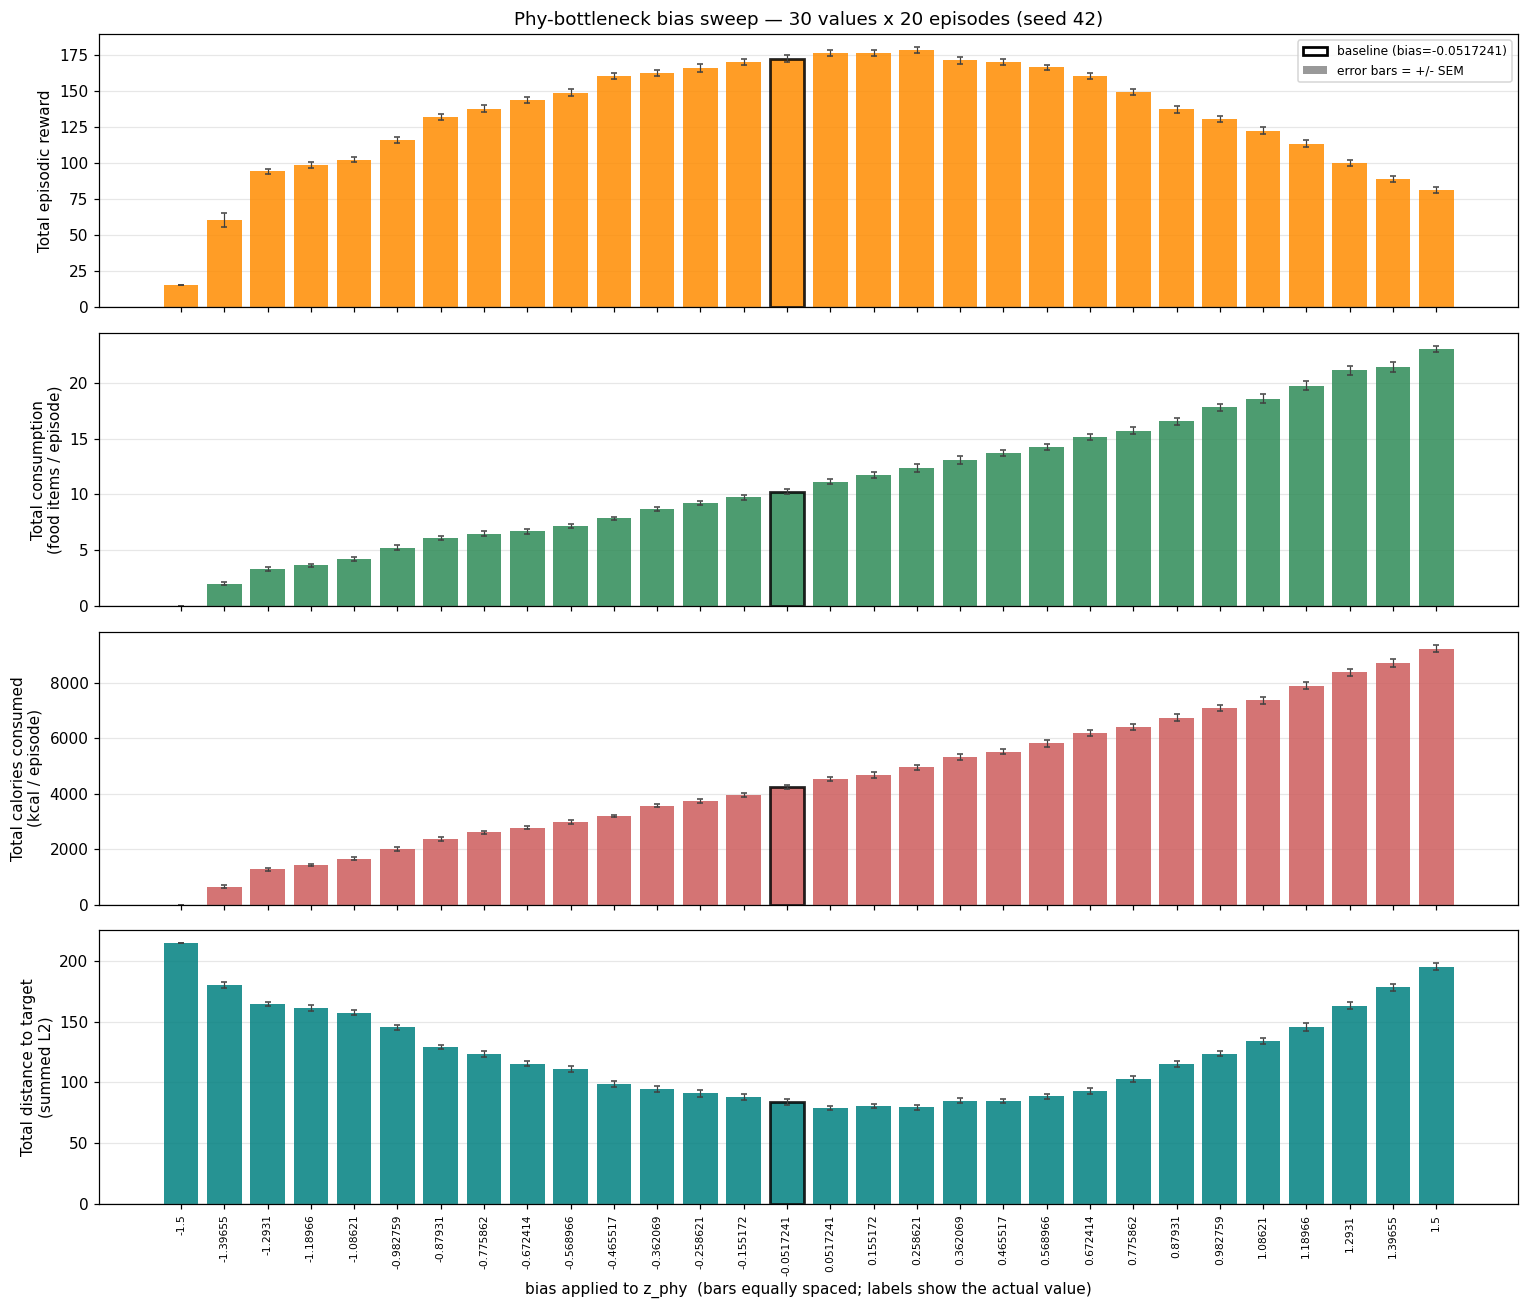

Saved results/plots_latent_ablation/bias_sweep_bars.png


In [ ]:
# ── Plot the sweep (bars; equidistant regardless of value spacing) ────────
from matplotlib.patches import Patch

a      = sweep_df['value'].values
x      = np.arange(len(a))
labels = [f'{v:g}' for v in a]

BASELINE_VAL = AMP_IDENTITY if SWEEP_AXIS == 'amplitude' else BIAS_IDENTITY
i_base = int(np.argmin(np.abs(a - BASELINE_VAL)))
i_abl  = int(np.argmin(np.abs(a - 0.0))) if SWEEP_AXIS == 'amplitude' else None

panels = [
    ('reward',      'Total episodic reward',                     'darkorange'),
    ('consumption', 'Total consumption\n(food items / episode)', 'seagreen'),
    ('calories',    'Total calories consumed\n(kcal / episode)', 'indianred'),
    ('distance',    'Total distance to target\n(summed L2)',     'teal'),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 3.0 * len(panels)), sharex=True)

for ax, (key, label, col) in zip(axes, panels):
    mu  = sweep_df[f'{key}_mean'].values
    sem = sweep_df[f'{key}_sem'].values
    bars = ax.bar(x, mu, yerr=sem, capsize=2, color=col, alpha=0.85,
                  error_kw=dict(lw=0.8, ecolor='0.25'))
    bars[i_base].set_edgecolor('black'); bars[i_base].set_linewidth(1.8)
    if i_abl is not None:
        bars[i_abl].set_edgecolor('0.35'); bars[i_abl].set_linewidth(1.4)
        bars[i_abl].set_hatch('//')
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_ylabel(label); ax.grid(alpha=0.3, axis='y'); ax.set_axisbelow(True)

legend_handles = [Patch(facecolor='white', edgecolor='black', lw=1.8,
                        label=f'baseline ({SWEEP_AXIS}={a[i_base]:g})')]
if i_abl is not None:
    legend_handles.append(Patch(facecolor='white', edgecolor='0.35', lw=1.4, hatch='//',
                                label=f'full ablation (amp={a[i_abl]:g})'))
legend_handles.append(Patch(facecolor='0.6', label='error bars = +/- SEM'))
axes[0].legend(handles=legend_handles, fontsize=8, loc='best')

axes[0].set_title(f'Phy-bottleneck {SWEEP_AXIS} sweep — {len(SWEEP_VALUES)} values '
                  f'x {N_SWEEP} episodes (seed {SEED_TO_LOAD})', fontsize=12)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels, rotation=90, fontsize=7)
axes[-1].set_xlabel(f'{SWEEP_AXIS} applied to z_phy  '
                    '(bars equally spaced; labels show the actual value)')
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'{SWEEP_AXIS}_sweep_bars.png'), bbox_inches='tight')
plt.show()
print(f'Saved {PLOT_DIR}/{SWEEP_AXIS}_sweep_bars.png')


### Reading the sweep

* **amplitude** scales `z_phy` multiplicatively: `amp=0` fully ablates the
  physiology signal, `amp=1` is baseline, `amp>1` amplifies it.
* **bias** shifts `z_phy` additively: negative → the agent behaves as if less
  hungry (under-eats), positive → over-eats. `bias=0` is baseline.
* A sign flip in `signed_err_mean` marks the transition between under- and
  over-eating. Peak reward is typically at (or near) the baseline; large
  departures on either axis degrade regulation.


## 5. Save all plotting data (pkl) + model metadata (json)

Persists every array the plots above use — the pooled per-step metrics for §1 and the single-instance slices behind the §2 nutrient and §3 `z_phy` grids — plus the sweep table and a paper-ready `model_metadata.json`. All into `PLOT_DIR`. Load `.pkl` with `pd.read_pickle` / `pickle.load`; nothing requires re-running the ablation.

In [ ]:
# === SAVE-ALL-ABLATION-DATA-AND-METADATA ===
# Consolidated save step. Runs after every section so all variables exist.
import pickle
from envs.env_config import NUTRIENT_CONFIG, SHADOW_NUTRIENT_CONFIG

def _save_pkl(obj, fname):
    p = os.path.join(PLOT_DIR, fname)
    with open(p, 'wb') as fh:
        pickle.dump(obj, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'Saved {p}')
    return p

nutrient_minmax = {nm: (float(env._nutrient_mins[nm]), float(env._nutrient_maxs[nm]))
                   for nm in names}

# ── (a) Per-condition capture — backs §1 (pooled) + §2/§3 (single instance) ─
conditions_capture = {
    'meta': {
        'conditions':       [{'amp': c['amp'], 'bias': c['bias'], 'label': c['label']}
                             for c in COND],
        'n_inference':      int(N_INFERENCE),
        'instance_episode': int(INSTANCE_EP),
        'selected_neurons': [int(j) for j in sel],
        'bottleneck':       BOTTLENECK_NAME,
        'eval_seed':        int(EVAL_SEED),
        'seed':             int(SEED_TO_LOAD),
        'nutrient_names':   list(names),
        'target_norm':      tgt, 'target_low': low, 'target_high': high,
        'nutrient_minmax':  nutrient_minmax,
        'sleep_windows':    sleep_wins,
    },
    'runs': {},
}
for c in COND:
    lab = c['label']
    r   = runs[lab]
    m   = r['episode_idx'] == INSTANCE_EP
    conditions_capture['runs'][lab] = {
        'amp': r['amp'], 'bias': r['bias'],
        # pooled per-step (for §1 mean/SEM curves)
        'reward':      r['rew'],
        'distance':    r['dist'],
        'signed':      r['signed'],
        'is_awake':    r['awake'],
        'episode_idx': r['episode_idx'],
        'cal_cum':     r['cal_cum'],        # (8640,) per-step cumulative kcal
        # single-instance slices (INSTANCE_EP) for §2 nutrient + §3 z_phy plots
        'phy_instance': r['phy'][m],          # (T, n_nut) normalised
        'z_instance':   r['z'][m],            # (T, z_dim)
        'ate_instance': r['ate'][m],          # (T,)
        'eat_steps':    np.where(r['ate'][m])[0],
        # per-episode scalar table
        'per_ep': r['per_ep'],
    }
_save_pkl(conditions_capture, 'conditions_capture.pkl')

# ── (b) Paper-ready model + ablation metadata (JSON) ───────────────────────
def _cond_results(pe):
    n = len(pe)
    return {
        'return_mean':          float(pe.total_reward.mean()),
        'return_sem':           float(pe.total_reward.std(ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
        'food_items_mean':      float(pe.total_consumption.mean()),
        'kcal_mean':            float(pe.total_calories.mean()),
        'avg_distance_mean':    float(pe.avg_distance.mean()),
        'avg_signed_err_mean':  float(pe.avg_signed_err.mean()),
    }

_best   = sweep_df.loc[sweep_df['reward_mean'].idxmax()]
_under  = sweep_df[sweep_df.signed_err_mean < 0]['value']
_over   = sweep_df[sweep_df.signed_err_mean > 0]['value']

model_metadata = {
    'checkpoint': {
        'meta_path':         CKPT_META,
        'name':              CKPT_NAME,
        'seed':              ckpt_meta.get('seed'),
        'shared':            bool(ckpt_meta.get('shared')),
        'hidden':            ckpt_meta.get('hidden'),
        'best_return':       ckpt_meta.get('best_return'),
        'best_episode':      ckpt_meta.get('best_episode'),
        'separate_branches': ckpt_meta.get('separate_branches'),
    },
    'ablation': {
        'bottleneck':               BOTTLENECK_NAME,
        'bottleneck_dim':           int(agent.list_bottlenecks()[BOTTLENECK_NAME]['dim']),
        'eval_seed':                int(EVAL_SEED),
        'deterministic':            bool(DETERMINISTIC),
        'n_inference_per_condition': int(N_INFERENCE),
        'instance_episode':         int(INSTANCE_EP),
        'selected_neurons':         [int(j) for j in sel],
        'conditions': [
            {'amp': c['amp'], 'bias': c['bias'], 'label': c['label'],
             'results': _cond_results(runs[c['label']]['per_ep'])}
            for c in COND
        ],
    },
    'sweep': {
        'axis':        SWEEP_AXIS,
        'values':      [float(v) for v in SWEEP_VALUES],
        'n_episodes':  int(N_SWEEP),
        'results':     sweep_df.to_dict(orient='records'),
        'peak_reward': {'value': float(_best['value']),
                        'reward_mean': float(_best['reward_mean'])},
        'under_eating_value_range': ([float(_under.min()), float(_under.max())]
                                     if len(_under) else None),
        'over_eating_value_range':  ([float(_over.min()), float(_over.max())]
                                     if len(_over) else None),
    },
    'env': {
        'food_folder':           env.food_folder,
        'num_foods':             int(env.num_foods),
        'num_items':             int(env.num_items),
        'food_items':            list(env.item_list),
        'max_steps':             int(env.max_steps),
        'awake_steps_per_cycle': int(env.awake_steps),
        'sleep_steps_per_cycle': int(env.sleep_steps),
        'cycle_length':          int(env.cycle_length),
        'minutes_per_step':      int(env.minutes_per_step),
        'is_continuous':         bool(env.is_continuous),
        'consumption_threshold': float(env.consumption_threshold),
    },
    'nutrient_config':        {nm: dict(cfg) for nm, cfg in NUTRIENT_CONFIG.items()},
    'shadow_nutrient_config': {nm: dict(cfg) for nm, cfg in SHADOW_NUTRIENT_CONFIG.items()},
}
_meta_path = os.path.join(PLOT_DIR, 'model_metadata.json')
with open(_meta_path, 'w') as fh:
    json.dump(model_metadata, fh, indent=2)
print(f'Saved {_meta_path}')
print(f'\nAll ablation plotting data + metadata written to {PLOT_DIR}')


Saved results/plots_latent_ablation/conditions_capture.pkl
Saved results/plots_latent_ablation/model_metadata.json

All ablation plotting data + metadata written to results/plots_latent_ablation
